#### Mini Project: Analyze a small dataset (e.g., student scores) to find distribution, variance, and summary stats

#### Aim : Analyze a small dataset (e.g., student scores) to find distribution, variance, and summary stats.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
print(os.listdir("."))

In [2]:
students_score = r".\student_scores.csv"
df = pd.read_csv(students_score)
print(f"Dataset loaded: {len(df)} students, {len(df.columns)} columns")

print("\nFirst few records:")

df.head()

Dataset loaded: 100 students, 5 columns

First few records:


,id,name,math_score,science_score,english_score
0,1,Student_1,88,58,64
1,2,Student_2,78,73,81
2,3,Student_3,64,50,81
3,4,Student_4,92,93,73
4,5,Student_5,57,57,90


In [3]:
df.describe()

,id,math_score,science_score,english_score
count,100.000000,100.000000,100.000000,100.00000
mean,50.500000,74.070000,74.450000,73.42000
std,29.011492,14.447575,14.078693,15.15721
min,1.000000,50.000000,50.000000,50.00000
25%,25.750000,63.000000,61.750000,60.00000
50%,50.500000,73.000000,76.500000,73.00000
75%,75.250000,88.000000,86.000000,85.25000
max,100.000000,99.000000,98.000000,99.00000


It's calculated by mean of square minus square of mean: Var(X)=E[(X−μ)^2]   where μ(mu) is the expected value (mean) of X

Variance in stats = how large of a spread there is within a data set

In [4]:
variance = df[["math_score", "science_score", "english_score"]].var()
print(variance)

math_score       208.732424
science_score    198.209596
english_score    229.741010
dtype: float64


In [5]:
from scipy import stats

subjects = ["math_score", "science_score", "english_score"]

for subject in subjects:
    scores = df[subject]

    mean = np.mean(scores)
    median = np.median(scores)
    mode = stats.mode(scores, keepdims=True).mode[0]
    variance = np.var(
        scores, ddof=1
    )  ##ddof= 1 : Bessel's correction, which provides an unbiased estimate for a sample standard deviation.
    std_dev = np.std(scores, ddof=1)

    print(f"\n{subject} statistics: ")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Variance: {variance}")
    print(f"Standard Deviation: {std_dev}")


math_score statistics: 
Mean: 74.07
Median: 73.0
Mode: 93
Variance: 208.73242424242426
Standard Deviation: 14.44757502982505

science_score statistics: 
Mean: 74.45
Median: 76.5
Mode: 88
Variance: 198.20959595959596
Standard Deviation: 14.078692977673601

english_score statistics: 
Mean: 73.42
Median: 73.0
Mode: 81
Variance: 229.74101010101012
Standard Deviation: 15.157209838918577


So as we can see (74, 74.45, 73.42) ≈ 73-74% success rate on a 100-point test

Scores: 74, 74.45, 73.42 ≈ 73–74%

### Scale to a 20-question test
20 × 0.74  = 14.8  
20 × 0.745 = 14.9  
20 × 0.734 = 14.7  

### Using E = n·p
p = 0.7  → 14  
p = 0.6  → 12  
p = 0.5  → 10


#### distributions (Normal, Binomial, Poisson)

#### Normal Distribution

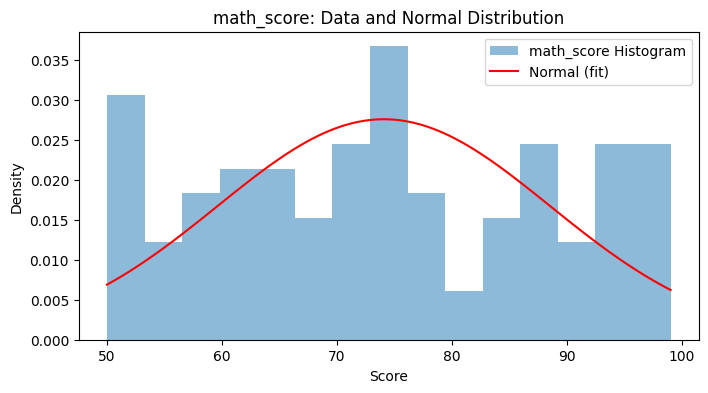

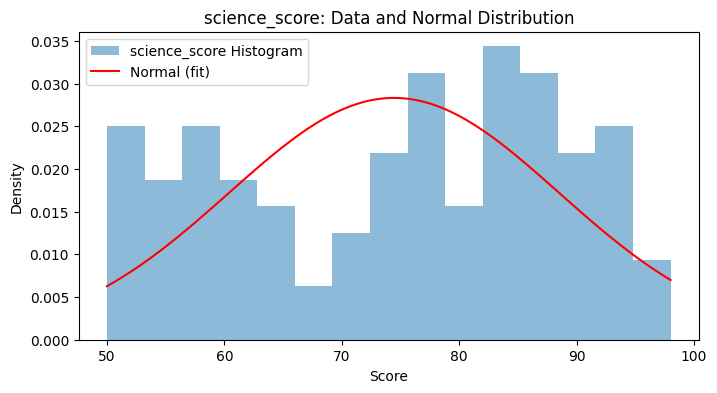

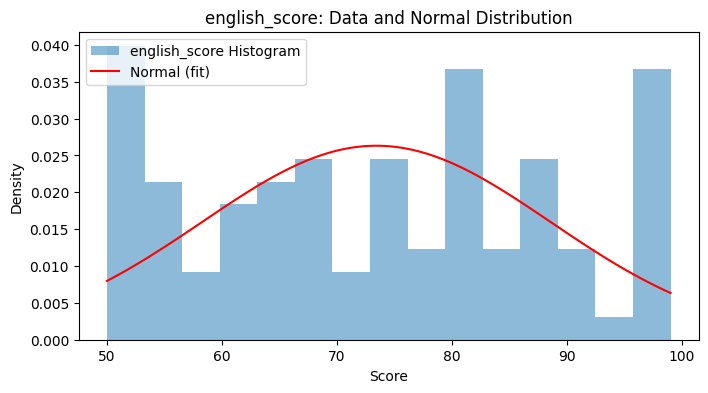

In [6]:
from scipy.stats import norm, binom, poisson

subjects = ["math_score", "science_score", "english_score"]

# Set example params for Binomial and Poisson for each subject
params = {
    "math_score": {"n": 20, "p": 0.7, "lam": 14},
    "science_score": {"n": 20, "p": 0.6, "lam": 12},
    "english_score": {"n": 20, "p": 0.5, "lam": 10},
}

for subject in subjects:
    data = df[subject]

    mu, sigma = data.mean(), data.std(ddof=1)
    x = np.linspace(data.min(), data.max(), 100)

    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=15, density=True, alpha=0.5, label=f"{subject} Histogram")
    plt.plot(x, norm.pdf(x, mu, sigma), "r", label="Normal (fit)")
    plt.title(f"{subject}: Data and Normal Distribution")
    plt.xlabel("Score")
    plt.ylabel("Density")
    plt.legend()

#### Binominal Distribution

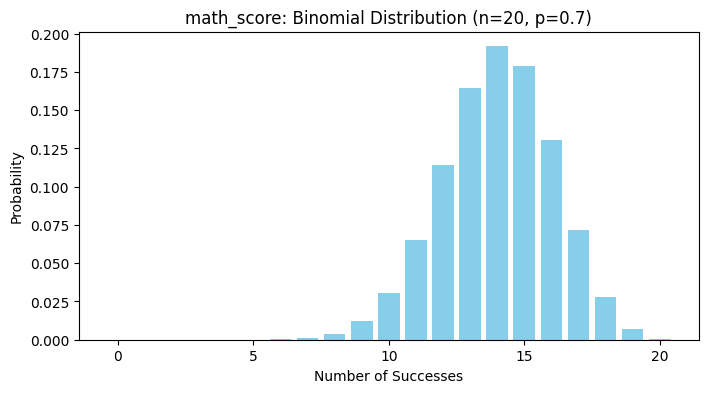

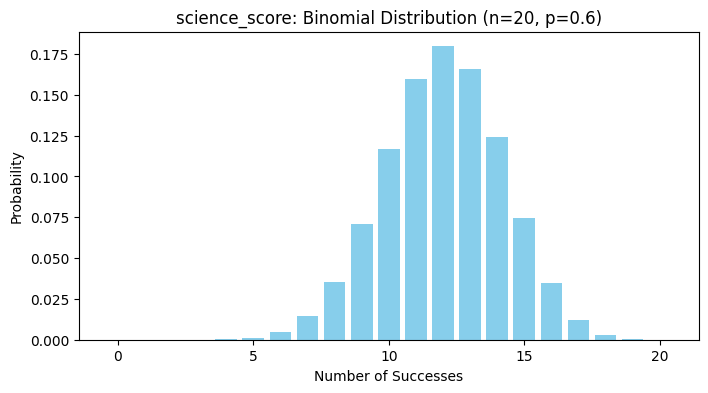

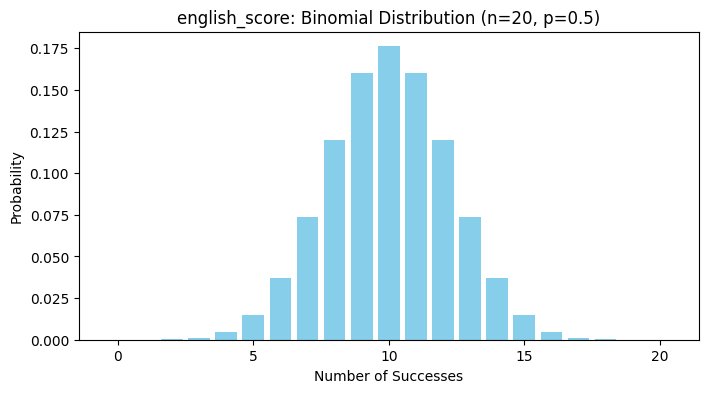

In [7]:
for subject in subjects:
    data = df[subject]
    n, p = params[subject]["n"], params[subject]["p"]
    x_bin = np.arange(0, n + 1)
    plt.figure(figsize=(8, 4))
    plt.bar(
        x_bin, binom.pmf(x_bin, n, p), color="skyblue"
    )  # probability mass function (PMF)
    plt.title(f"{subject}: Binomial Distribution (n={n}, p={p})")
    plt.xlabel("Number of Successes")
    plt.ylabel("Probability")

#### Poisson Distribution

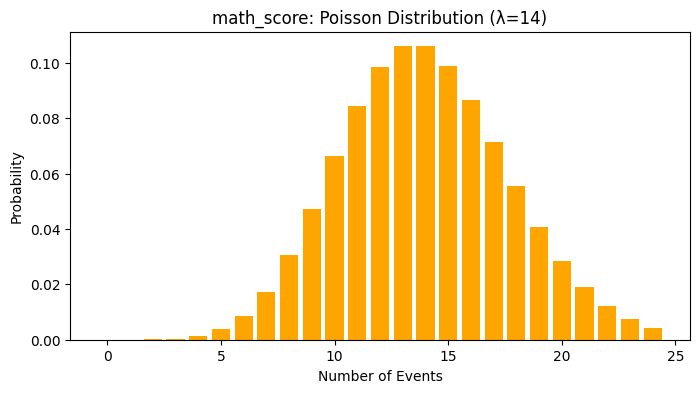

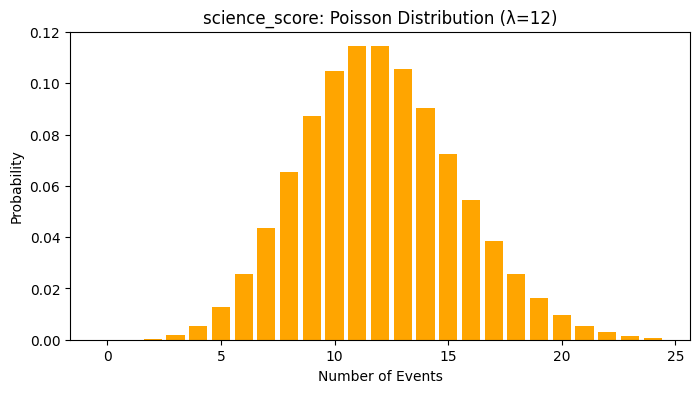

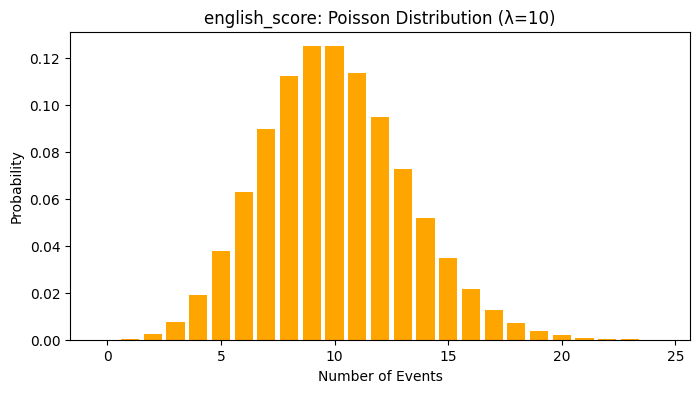

In [8]:
for subject in subjects:
    data = df[subject]

    lam = params[subject]["lam"]
    x_pois = np.arange(0, n + 5)
    plt.figure(figsize=(8, 4))
    plt.bar(x_pois, poisson.pmf(x_pois, lam), color="orange")
    plt.title(f"{subject}: Poisson Distribution (λ={lam})")
    plt.xlabel("Number of Events")
    plt.ylabel("Probability")

**Summary of Performance Across Subjects**

- All three subjects show similar average performance around **73–74 points**  
  (Math: **74.07**, Science: **74.45**, English: **73.42**), indicating balanced ability across subjects.

- **Medians (73–76.5)** closely match the means, suggesting roughly normal distributions with no major outliers.

- **Science** has the lowest variance (**198.21**) and standard deviation (**14.08**), meaning it has the most consistent scores.  
  **English** shows the highest spread (variance **229.74**, SD **15.16**).

- The most common scores (modes) were:  
  - Math: **93**  
  - Science: **88**  
  - English: **81**  
  indicating majority of high performers in each subject.

- Histograms and KDE curves appear **bell-shaped**, suggesting the data fits a normal distribution fairly well.

- Scaling to a 20-question model:  
  - Approx. 74% success → expected scores around **14–15**  
  - Binomial examples: **p = 0.7 → 14**, **p = 0.6 → 12**, **p = 0.5 → 10**  
  - Poisson approximations use **λ = 14, 12, 10** accordingly.
